# BurnAway AI — Developer Burnout Prediction System

**Objective:** Membangun *multi-task deep learning model* untuk melakukan klasifikasi level *burnout developer* (Low / Medium / High) berdasarkan *behavioral metrics* dan data kesehatan, serta memberikan *personalized recommendations* menggunakan *advisory layer* berbasis Gemini.

**Pipeline Overview:**
```
Data Ingestion → EDA → Preprocessing → Feature Scaling → SMOTE → tf.data Pipeline
→ Cross-Validation → Model Training (Custom Loop) → Evaluation → Inference → Export
```

---

# 1. Environment Setup

Tahap ini meload seluruh *dependencies* yang dibutuhkan. Library yang diimpor mencakup modul untuk manipulasi data (`NumPy`, `Pandas`), visualisasi (`Matplotlib`, `Seaborn`), *deep learning* (`TensorFlow / Keras`), preprocessing (`Scikit-Learn`, `imbalanced-learn`), dan Gemini *generative* AI SDK.

Blok `try/except` digunakan untuk melakukan import `google-genai` secara aman dan mengeset flag `GENAI_SDK_AVAILABLE`. Jika SDK tersebut absen dari environment, pipeline akan secara otomatis memutar *routing* ke jalur *REST API fallback*, memastikan alur eksekusi tetap aman tanpa interupsi.

In [86]:
import os
import pickle
import time
from datetime import datetime
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.metrics import CategoricalAccuracy, MeanAbsoluteError

try:
    from google import genai
    GENAI_SDK_AVAILABLE = True
except ImportError:
    GENAI_SDK_AVAILABLE = False
    print("[INFO] google-generativeai tidak terinstall. Fallback ke requests API.")

warnings.filterwarnings("ignore")
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")
print(f"GenAI SDK          : {'Tersedia' if GENAI_SDK_AVAILABLE else 'Tidak tersedia (pakai requests fallback)'}")


TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2
GenAI SDK          : Tersedia


# 2. Global Configuration & Hyperparameters

Semua konfigurasi parameter (*hyperparameters*), *file paths*, serta variabel konstanta dipusatkan di sini. Jika ingin memodifikasi parameter eksperimen, cukup ubah variabel-variabel di dalam *cell* ini saja.

| Category | Key Parameters | Description |
|:---|:---|:---|
| **Data** | `TARGET_COLUMN`, `NUM_CLASSES`, `TEST_SIZE` | Kolom target prediksi, jumlah kelas klasifikasi, dan rasio partisi data untuk *held-out test split* |
| **Training** | `BATCH_SIZE`, `EPOCHS`, `LEARNING_RATE` | Kontrol *schedule* iterasi optimisasi sentral selama model ditraining |
| **Architecture** | `ATTENTION_UNITS`, `DROPOUT_RATES` | Lebar arsitektur pemetaan *embedding* dari layer FT-Transformer serta rasio *dropout regularization*-nya |
| **Custom Loss** | `FOCAL_GAMMA`, `FOCAL_ALPHA`, `LABEL_SMOOTHING` | Variabel konfigurasi Focal Loss untuk menyiasati problem *class imbalance* |
| **Generative AI** | `GEMINI_MODEL`, `AI_TEMPERATURE` | Konfigurasi *model tuning* LLM untuk subsistem *advisory recommendation layer* |

*Output directories* (`models/`, `api/`, `logs/`) akan dikonstruksi secara *programmatic* pada bagian akhir blok ini.

In [87]:
# Paths
DATA_URL         = "https://drive.google.com/uc?export=download&id=1TAJqEavYCdsi3Ry1anrt6bedkrPRcEXF"
DATASET_PATH     = "burnout_main_data.csv"
MODEL_SAVE_DIR   = Path("models")
MODEL_BEST_PATH  = MODEL_SAVE_DIR / "burnaway_model_best.keras"
MODEL_FINAL_PATH = MODEL_SAVE_DIR / "burnaway_model.keras"
API_DIR          = Path("api")
LOG_DIR          = Path("logs") / "fit" / datetime.now().strftime("%Y%m%d-%H%M%S")

# Reproducibility
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Data
TARGET_COLUMN = "burnout_level"
NUM_CLASSES   = 3
TEST_SIZE     = 0.10
VAL_SIZE      = 0.10
CLASS_LABELS  = {0: "Low", 1: "Medium", 2: "High"}
OUTLIER_COL = "commit_bug_ratio"
OUTLIER_CLIP_Q = 0.99
REGRESSION_TARGET_COLUMN = 'stress_level' # Add this line

# Training
BATCH_SIZE             = 32
EPOCHS                 = 30
LEARNING_RATE          = 1e-3
GRAD_CLIP              = 1.0
L2_REG_FACTOR          = 1e-4
MIN_EPOCHS_BEFORE_SAVE = 10

# Performance Targets
TARGET_ACCURACY = 0.85
TARGET_MAE      = 0.02

# Model Architecture
ATTENTION_UNITS = 64
DROPOUT_RATES   = [0.15, 0.1, 0.05]

# Custom Components
LABEL_SMOOTHING = 0.05
FOCAL_GAMMA     = 0.5
FOCAL_ALPHA     = 0.25

# Generative AI Configuration
GEMINI_API_KEY  = os.environ.get("GEMINI_API_KEY", "")
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/models"
GEMINI_MODEL    = "gemini-2.5-flash"

# Pembuatan direktori output (logs, model artifacts, dll)
for d in [MODEL_SAVE_DIR, API_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(" CONFIGURATION ".center(60, '='))
config_groups = {
    "PATHS AND DIRECTORIES": {"Dataset Path": DATASET_PATH, "Model Save Dir": MODEL_SAVE_DIR, "Log Dir": LOG_DIR},
    "TRAINING HYPERPARAMETERS": {"Batch Size": BATCH_SIZE, "Epochs": EPOCHS, "Learning Rate": LEARNING_RATE, "Random Seed": RANDOM_SEED},
    "MODEL TARGETS AND ARCHITECTURE": {"Target Accuracy": f"{TARGET_ACCURACY*100}%", "Target MAE": TARGET_MAE, "Attention Units": ATTENTION_UNITS, "Num Classes": NUM_CLASSES},
    "GENERATIVE AI (GEMINI)": {"Model Name": GEMINI_MODEL, "API Status": "CONNECTED" if GEMINI_API_KEY else "NOT FOUND"}
}

for group, details in config_groups.items():
    print(f"\n[{group}]")
    for key, value in details.items():
        print(f"  - {key:<15} : {value}")

====================== CONFIGURATION =======================

[PATHS AND DIRECTORIES]
  - Dataset Path    : burnout_main_data.csv
  - Model Save Dir  : models
  - Log Dir         : logs/fit/20260513-091506

[TRAINING HYPERPARAMETERS]
  - Batch Size      : 32
  - Epochs          : 30
  - Learning Rate   : 0.001
  - Random Seed     : 42

[MODEL TARGETS AND ARCHITECTURE]
  - Target Accuracy : 85.0%
  - Target MAE      : 0.02
  - Attention Units : 64
  - Num Classes     : 3

[GENERATIVE AI (GEMINI)]
  - Model Name      : gemini-2.5-flash
  - API Status      : NOT FOUND


# 3. Utility Functions

Berisi kumpulan *helper functions* yang dapat di-*reuse* guna memastikan prinsip **DRY** (*Don't Repeat Yourself*) tetap terjaga di sepanjang kode pipeline eksperimen ini.

| Function | Purpose |
|:---|:---|
| `set_global_seed` | Mengunci *random state* pada Python, NumPy, dan TensorFlow supaya eksperimen memiliki *full reproducibility* |
| `validate_dataframe` | Menjalankan *automated data health checks* — mencakup pengecekan *shape*, inspeksi *null counts*, dan memvalidasi presensi *required columns* |
| `log_metric` | Membantu format pencetakan teks metrik dengan *aligned columns* yang lebih rapi |
| `check_target_achieved` | Mengkomparasikan performa model terhadap *predefined threshold* untuk akurasi (≥ 85%) maupun MAE (≤ 0.02) |
| `print_split_summary` | Me-*render* *formatted summary table* untuk rekapitulasi distribusi partisi dataset Train / Validation / Test |

In [88]:
def set_global_seed(seed: int) -> None:
    """
    Menjamin konsistensi hasil eksperimen (reproducibility) dengan mengunci angka acak pada Python, NumPy, dan TensorFlow.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def validate_dataframe(df: pd.DataFrame, required_cols: list = None, name: str = "DataFrame") -> None:
    """
    Melakukan pemeriksaan kesehatan data: deteksi data kosong, nilai null, dan ketersediaan kolom wajib.
    """
    if df.empty:
        raise ValueError(f"[ERROR] '{name}' kosong. Periksa sumber data Anda.")

    null_counts = df.isnull().sum()
    total_nulls = int(null_counts.sum())

    print(f"\n[INFO] Validasi {name}:")
    print(f"  |-- Dimensi Data    : {df.shape[0]} baris, {df.shape[1]} kolom")
    print(f"  |-- Total Null      : {total_nulls}", end=" ")

    if total_nulls > 0:
        print(f"\n  |-- Detail Null per Kolom:")
        print(null_counts[null_counts > 0].to_string(header=False))
    else:
        print("(Bersih)")

    # Menampilkan ringkasan data types (*dtypes*)
    dtype_summary = df.dtypes.value_counts().to_dict()
    print(f"  |-- Komposisi Tipe  : {dtype_summary}")

    # Memastikan requirement kolom ada dalam dataset
    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"[ERROR] Kolom wajib hilang: {missing}")


def log_metric(name: str, value: float) -> None:
    """Mencetak metrik evaluasi dengan format kolom yang sejajar."""
    print(f"  {name:<20}: {value:.6f}")


def check_target_achieved(accuracy: float, mae: float) -> str:
    """
    Membandingkan performa model dengan target ambang batas
    yang telah ditentukan di Konfigurasi Global.
    """
    acc_status = "TERCAPAI" if accuracy >= TARGET_ACCURACY else "BELUM TERCAPAI"
    mae_status = "TERCAPAI" if mae <= TARGET_MAE else "BELUM TERCAPAI"

    return (
        f"Akurasi: {accuracy * 100:.2f}% [{acc_status}] | "
        f"MAE: {mae:.4f} [{mae_status}]"
    )


def print_split_summary(X_train: np.ndarray, X_val: np.ndarray, X_test: np.ndarray) -> None:
    """Menampilkan tabel ringkasan pembagian dataset (Train, Val, Test)."""
    total = len(X_train) + len(X_val) + len(X_test)

    print(f"\n  {'Kategori':<12} {'Jumlah Baris':>12} {'Persentase':>12}")
    print(f"  {'-'*38}")

    datasets = [("Train", X_train), ("Validation", X_val), ("Test", X_test)]
    for name, data in datasets:
        count = len(data)
        percent = (count / total) * 100
        print(f"  {name:<12} {count:>12} {percent:>11.1f}%")

    print(f"  {'-'*38}")
    print(f"  {'Total':<12} {total:>12} {'100.0%':>12}")


# Initialize Utilities
set_global_seed(RANDOM_SEED)
print("[SUCCESS] Fungsi utilitas telah siap digunakan.")

[SUCCESS] Fungsi utilitas telah siap digunakan.


# 4. Data Loading & Exploratory Analysis

Fungsi `load_dataset` mengimplementasikan strategi **local-first**: skrip akan melacak *cached CSV file* sebelum melakukan langkah *download* paket dari *configured Google Drive URL*. Sesudah terload penuh, fungsi perbantuan `validate_dataframe` segera dipanggil untuk memverifikasi integritas skema data.

**Fokus *initial inspection*:**
- **Schema validation** — mengkonfirmasi bahwa seluruh 15 *feature columns* adalah variabel bertipe numerik.
- **Class distribution** — mengidentifikasi *potential imbalance* di lintas kategori level Low / Medium / High burnout.
- **Descriptive statistics** — mendeteksi *value range anomalies* dan melacak gejala kehadiran *potential outliers* sebelum tahapan *preprocessing*.

[INFO] Mengakses dataset lokal: burnout_main_data.csv

[INFO] Validasi Burnout Dataset:
  |-- Dimensi Data    : 7000 baris, 16 kolom
  |-- Total Null      : 0 (Bersih)
  |-- Komposisi Tipe  : {dtype('float64'): 14, dtype('int64'): 2}

        RINGKASAN STRUKTUR DATA         
           Nama Kolom Tipe Data
                  age   float64
     experience_years   float64
     daily_work_hours   float64
          sleep_hours   float64
      caffeine_intake   float64
         bugs_per_day   float64
      commits_per_day   float64
     meetings_per_day   float64
          screen_time   float64
       exercise_hours   float64
         stress_level   float64
        burnout_level     int64
     work_sleep_ratio   float64
screen_time_intensity   float64
     commit_bug_ratio   float64
        work_category     int64

[ANALISIS] Visualisasi distribusi target 'burnout_level':


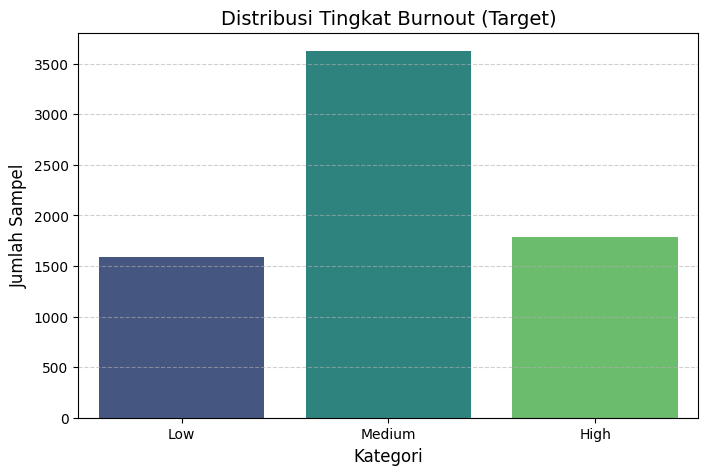


[ANALISIS] Ringkasan statistik fitur numerik:


,count,mean,std,min,25%,50%,75%,max
age,7000.0,32.126857,7.157599,20.000000,26.000000,32.000000,38.000000,44.000000
experience_years,7000.0,9.589429,5.703364,0.000000,5.000000,10.000000,15.000000,19.000000
daily_work_hours,7000.0,9.000071,2.835156,4.000000,6.607500,8.990000,11.370000,14.000000
sleep_hours,7000.0,6.485126,1.430488,4.000000,5.250000,6.460000,7.710000,9.000000
caffeine_intake,7000.0,3.549857,2.261406,0.000000,2.000000,4.000000,5.000000,7.000000
bugs_per_day,7000.0,9.473000,5.694249,0.000000,5.000000,9.000000,14.000000,19.000000
commits_per_day,7000.0,14.449286,8.582937,0.000000,7.000000,14.000000,22.000000,29.000000
meetings_per_day,7000.0,4.554143,2.828768,0.000000,2.000000,5.000000,7.000000,9.000000
screen_time,7000.0,11.975677,3.060138,5.210000,9.520000,12.020000,14.362500,18.930000
exercise_hours,7000.0,1.007859,0.570913,0.000000,0.520000,1.020000,1.490000,2.000000


In [89]:
def load_dataset(url: str, local_path: str) -> pd.DataFrame:
    """
    Memuat dataset dengan prioritas penyimpanan lokal. Jika tidak ada,
    data akan diunduh dari URL dan disimpan secara otomatis.
    """
    if os.path.exists(local_path):
        print(f"[INFO] Mengakses dataset lokal: {local_path}")
        df = pd.read_csv(local_path)
    else:
        print(f"[INFO] Dataset lokal tidak ditemukan. Mengunduh dari sumber eksternal...")
        # Fetch data langsung ke pandas DataFrame
        df = pd.read_csv(url)
        # Simpan local cache agar sesi notebook berikutnya lebih cepat (avoid re-download)
        df.to_csv(local_path, index=False)
        print(f"[SUCCESS] Dataset berhasil diunduh dan disimpan di: '{local_path}'")

    # Panggil *utility function* untuk memvalidasi *dataframe*
    validate_dataframe(df, required_cols=[TARGET_COLUMN], name="Burnout Dataset")
    return df

# Eksekusi Pemuatan Data
df_raw = load_dataset(DATA_URL, DATASET_PATH)

# Exploratory Data Analysis (EDA)
print("\n" + "="*40)
print(f"{'RINGKASAN STRUKTUR DATA':^40}")
print("="*40)

# Print out informasi data type dengan style tabel
dtype_df = df_raw.dtypes.reset_index()
dtype_df.columns = ['Nama Kolom', 'Tipe Data']
print(dtype_df.to_string(index=False))

# Visualisasi Distribusi Target
print(f"\n[ANALISIS] Visualisasi distribusi target '{TARGET_COLUMN}':")
target_distribution = df_raw[TARGET_COLUMN].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=[CLASS_LABELS[i] for i in target_distribution.index],
    y=target_distribution.values,
    palette='viridis'
)
plt.title('Distribusi Tingkat Burnout (Target)', fontsize=14)
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Descriptive Statistics
print(f"\n[ANALISIS] Ringkasan statistik fitur numerik:")
display(df_raw.describe().T) # Di-transpose (.T) agar lebih mudah dibaca jika kolom banyak

# 5. Data Preprocessing

Data *raw* kita ditransformasi menjadi sebuah format *model-ready tensor* menggunakan tiga tahapan *preprocessing* secara sekuensial.

**1. Outlier Clipping** — Kolom variabel `commit_bug_ratio` terpantau memuat sekumpulan *extreme values* yang bakal mendistorsi hitungan *gradient magnitude*. Nilai di atas *99th percentile* lalu kita *clip* untuk menghindari distorsi selama langkah *backpropagation*.

**2. Target Encoding & Validation** — Kolom target `burnout_level` di-*cast* menjadi `int32` dan divalidasi terhadap referensi kategori yang sah `{0, 1, 2}`. Persentase grafik distribusi dicatat rapi buat mendeteksi *class balance* sebelum displit.

**3. Type Casting (float32)** — Matriks fitur dikonversikan menjadi wujud `np.float32`, yaitu standar *dtype* yang *memory-efficient* bagi keperluan *GPU/TPU computation matrix* di TensorFlow.

In [90]:
def clip_column_outliers(df: pd.DataFrame, col: str, upper_quantile: float) -> pd.DataFrame:
    """
    Membatasi nilai ekstrem (outlier) agar tidak mengacaukan gradien saat training.
    """
    df_out = df.copy()
    upper_bound = df_out[col].quantile(upper_quantile)

    # Proses Clipping
    df_out[col] = df_out[col].clip(upper=upper_bound)

    print(f"[INFO] Outlier Clipping '{col}':")
    print(f"  |-- Max Sebelumnya : {df[col].max():.2f}")
    print(f"  |-- Max Sesudah    : {df_out[col].max():.2f} (Quantile {upper_quantile})")
    return df_out

def encode_burnout_target(series: pd.Series) -> np.ndarray:
    """
    Memastikan label target bertipe integer {0, 1, 2} dan menampilkan distribusinya.
    """
    encoded = series.astype(np.int32).values
    unique_values = set(np.unique(encoded))
    expected = {0, 1, 2}

    if not unique_values.issubset(expected):
        raise ValueError(f"Target error! Ditemukan nilai {unique_values}, diharapkan {expected}.")

    print(f"\n{' TARGET ENCODING SUMMARY ':\^40}")
    print("-" * 40)
    for code, label in CLASS_LABELS.items():
        count = int(np.sum(encoded == code))
        pct = count / len(encoded)
        print(f"  [{code}] {label:<7} : {count:>5} sampel ({pct:>5.1%})")
    return encoded

# 1. Handling Outliers
df_clean = clip_column_outliers(df_raw, OUTLIER_COL, OUTLIER_CLIP_Q)

# 2. Splitting Feature matrix (X), Classification target (y_clf) & Regression target (y_reg)
# Redefine FEATURE_COLS to exclude both classification and regression targets
FEATURE_COLS = [c for c in df_clean.columns if c not in [TARGET_COLUMN, REGRESSION_TARGET_COLUMN]]

X_full = df_clean[FEATURE_COLS].values.astype(np.float32)
y_clf_full = encode_burnout_target(df_clean[TARGET_COLUMN]).astype(np.int32)
# Normalize stress_level to 0-1 as the model's regression head uses sigmoid
y_reg_full = (df_clean[REGRESSION_TARGET_COLUMN] / 100.0).values.astype(np.float32)

print("\n" + "="*40)
print(f"Dataset Akhir: {X_full.shape[0]} baris, {X_full.shape[1]} fitur")
print(f"Class target shape: {y_clf_full.shape}")
print(f"Regression target shape: {y_reg_full.shape}")
print("="*40)

[INFO] Outlier Clipping 'commit_bug_ratio':
  |-- Max Sebelumnya : 290.00
  |-- Max Sesudah    : 220.00 (Quantile 0.99)

\\\\\\\ TARGET ENCODING SUMMARY \\\\\\\\
----------------------------------------
  [0] Low     :  1593 sampel (22.8%)
  [1] Medium  :  3625 sampel (51.8%)
  [2] High    :  1782 sampel (25.5%)

Dataset Akhir: 7000 baris, 14 fitur
Class target shape: (7000,)
Regression target shape: (7000,)


# 6. Dataset Splitting

Seluruh dataset dipecah menjadi tiga partisi *subsets* *non-overlapping* secara komprehensif menggunakan modul **Stratified Shuffle Split**, di mana porsi sebaran rasio per-kelasnya bakal dijaga dengan konsisten.

| Split | Ratio | Role |
|:---|:---|:---|
| **Training** | 80% | Sumber data iterasi bagi kalkulasi parameter *gradient-based weight updates* di model |
| **Validation** | 10% | Acuan evaluasi performa model (*generalization*) dan memandu parameter *early stopping* |
| **Test (hold-out)** | 10% | Ujian final; sama sekali tak dilihat algoritma saat pelatihan atau iterasi *tuning* |

Dengan menerapkan parameter `stratify=y`, sebaran porsi perwakilan entitas burnout tingkat Low / Medium / High di seluruh *splits* akan terproyeksi identik seperti formasi aslinya, mencegah isu *skewed distribution*.

In [91]:
# Tahap 1: Ekstraksi kumpulan Data Test (Hold-out Set)
X_train_val, X_test, y_clf_train_val, y_clf_test, y_reg_train_val, y_reg_test = train_test_split(
    X_full, y_clf_full, y_reg_full, # Split all three: features, classification target, regression target
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_clf_full,  # Stratify based on classification target
)

# Tahap 2: Memisahkan Data Train dan Validation dari sisa data
# Hitung rasio validation relatif terhadap data train_val
val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_clf_train, y_clf_val, y_reg_train, y_reg_val = train_test_split(
    X_train_val, y_clf_train_val, y_reg_train_val,
    test_size=val_ratio,
    random_state=RANDOM_SEED,
    stratify=y_clf_train_val, # Stratify based on classification target
)

# Print hasil pembagian data (split summary)
print_split_summary(X_train, X_val, X_test)


  Kategori     Jumlah Baris   Persentase
  --------------------------------------
  Train                5600        80.0%
  Validation            700        10.0%
  Test                  700        10.0%
  --------------------------------------
  Total                7000       100.0%


# 7. Feature Scaling — RobustScaler

Seluruh *numerical features* distandarisasi menggunakan **`RobustScaler`**, yang menerapkan strategi sentralisasi pemusatan letak *median-centering* ditambah jangkauan rentang *IQR-based scaling* ketimbang berfokus pada sebaran purata varians populasi (*mean/std*).

**Kenapa *RobustScaler* ketimbang *StandardScaler*?** *Burnout datasets* pada lazimnya sering menyimpan profil *extreme behavioral values* (misal durasi kerja lembur berlebih, *elevated bug ratios*). *Mean-based scaling* bakal serta-merta menyeret tarikan deviasi distribusi memburu data tersebut; sementara metode *IQR-based scaling* lebih resisten dari ancaman *outliers*, menghasilkan formasi *gradient landscape* yang lebih stabil sewaktu *training*.

**Data Leakage Prevention:** `fit_transform()` secara disiplin diaplikasikan murni berpusat ke array `X_train` saja! Porsi *validation array* (`X_val`) dan *hold-out test array* (`X_test`) cukup dialih-fungsikan lewat `.transform()` menggunakan parameter skema dari *training data only*. Kebiasaan ini memberi penjaminan guna mencegah terjadinya bocoran info statisik (*data leakage*) menyusup ke ranah *model feature space*.

In [92]:
# Setup RobustScaler instance untuk menangani data ber-outlier
scaler = RobustScaler()

# Fit strictly pada X_train saja guna mencegah Data Leakage
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)

# Terapkan .transform() ke X_val dan X_test dengan scaler dari Train
X_val_scaled   = scaler.transform(X_val).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)

# Mendapatkan jumlah fitur input untuk konfigurasi model
INPUT_SIZE = X_train_scaled.shape[1]

print("\n" + "="*45)
print(" FEATURE NORMALIZATION REPORT ".center(45))
print("="*45)
print(f"  - Scaler Type       : {type(scaler).__name__}")
print(f"  - Input Size        : {INPUT_SIZE} Features")
print(f"  - Train Mean (std)  : {X_train_scaled.mean():.4f}")
print(f"  - Status            : SUCCESS")
print("="*45)


         FEATURE NORMALIZATION REPORT        
  - Scaler Type       : RobustScaler
  - Input Size        : 14 Features
  - Train Mean (std)  : 0.2425
  - Status            : SUCCESS


# 8. Class Imbalance Handling — SMOTE

Teknik **SMOTE** (Synthetic Minority Over-sampling Technique) menghasilkan sampel data sintetik baru dengan strategi interpolasi linear di antara *minority-class nearest neighbors*, alih-alih cuma menduplikasi persis *data points* aslinya.

**Effect on training:**
- Mendikte kerangka model agar mampu membangun batasan formasi pembeda (*sharper decision boundaries*) untuk melokalisir tiap level burnout secara akurat.
- Mereduksi level kelemahan pembiasan probabilitasnya (*reduces bias toward the majority class*) tanpa resiko manipulasi sebaran letak data dari metode replikasi duplikat.

**Scope:** Aplikasi SMOTE murni difokuskan hanya kepada porsi `X_train_scaled`. Kumpulan data *validation* serta sel *hold-out test* bakal dibiarkan tetap *original* supaya hasil *evaluation metrics*-nya sanggup merefleksikan kapabilitas ketahanan model pada *real-world conditions*.

[INFO] Penyeimbangan data selesai.
  |-- Jumlah sampel sebelum SMOTE : 5600
  |-- Jumlah sampel sesudah SMOTE : 8697


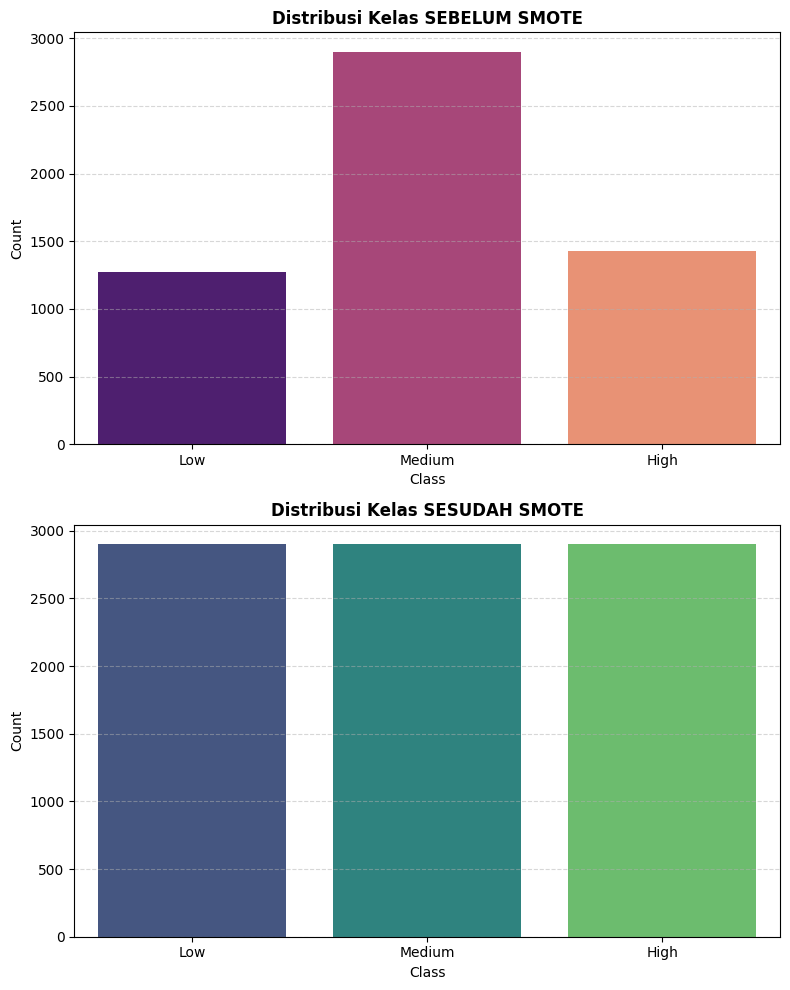

In [93]:
# Init SMOTE object untuk upsampling minority class secara *synthetic interpolation*
smote = SMOTE(random_state=RANDOM_SEED)
X_train_res, y_clf_train_res = smote.fit_resample(X_train_scaled, y_clf_train)

# Konversi hasil ke float32 dtype (*TensorFlow optimized*)
X_train_res = X_train_res.astype(np.float32)
y_clf_train_res = y_clf_train_res.astype(np.int32)

# Align regression targets with resampled indices using Nearest Neighbors
# Find the k-nearest neighbors in original X_train_scaled for each sample in X_train_res
# and use their corresponding y_reg_train value.
# n_jobs=-1 is added for potential parallel processing, common in production settings
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(X_train_scaled)
_, indices = nn.kneighbors(X_train_res)
y_reg_train_res = y_reg_train[indices.flatten()].astype(np.float32)

print(f"[INFO] Penyeimbangan data selesai.")
print(f"  |-- Jumlah sampel sebelum SMOTE : {X_train_scaled.shape[0]}")
print(f"  |-- Jumlah sampel sesudah SMOTE : {X_train_res.shape[0]}")

# Persiapan data untuk visualisasi perbandingan
def get_class_df(labels):
    counts = {CLASS_LABELS[cls]: int(np.sum(labels == cls)) for cls in [0, 1, 2]} # Fixed this line
    return pd.DataFrame(list(counts.items()), columns=['Class', 'Count'])

df_before = get_class_df(y_clf_train)
df_after  = get_class_df(y_clf_train_res)

# Visualisasi perbandingan Class Distribution Sebelum vs Sesudah SMOTE
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot Sebelum SMOTE
sns.barplot(x='Class', y='Count', data=df_before, ax=axes[0], palette='magma')
axes[0].set_title('Distribusi Kelas SEBELUM SMOTE', fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot Sesudah SMOTE
sns.barplot(x='Class', y='Count', data=df_after, ax=axes[1], palette='viridis')
axes[1].set_title('Distribusi Kelas SESUDAH SMOTE', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 9. Input Pipeline — tf.data

Array NumPy hasil *preprocessing* kita bungkus ke dalam objek `tf.data.Dataset`. Arsitektur ini mengkonfigurasi rute *data delivery* yang sangat *optimized* bagi eksekusi GPU/TPU.

**Optimizations applied:**
- **Batching** — Menyekat ribuan iterasi data menjadi *fixed-size batches* demi menjaga kestabilan *gradient updates* serta menghemat *memory efficiency*.
- **Shuffling** — Mengacak urutan masukan data pada setiap *epoch* agar menyabotase kemungkinan manuver memanipulasi *sequence artifacts*.
- **Prefetching (`AUTOTUNE`)** — Menjalankan pergerakan data persiapan secara *background* di CPU, bersandingan rapat dengan eksekusi perhitungan *training computation matrix* (GPU execution stream) untuk meruntuhkan perlambatan performa *device-transfer bottlenecks*.

Setiap sel data elemen akan mengirimkan sepasang parameter matriks kombinasi *(features, labels)* dalam bentukan sebaran dimensi `(BATCH_SIZE, INPUT_SIZE)` dan format vektor target `(BATCH_SIZE,)`.

In [94]:
def create_tf_dataset(X, y_clf, y_reg, batch_size=32, shuffle=False):
    """
    Membuat dataset yang mengembalikan (features, y_classification, y_regression).
    """
    # Pastikan tipe data benar (float32 untuk fitur/regresi, int32 untuk klasifikasi)
    ds = tf.data.Dataset.from_tensor_slices((
        tf.cast(X, tf.float32),
        tf.cast(y_clf, tf.int32),
        tf.cast(y_reg, tf.float32)
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(X))

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Pastikan Anda sudah menyiapkan y_train_reg, y_val_reg, dan y_test_reg (stress_level yang dinormalisasi 0-1)
# Contoh jika stress_level ada di kolom 'stress_level' (0-100):
# y_train_reg = X_train['stress_level'].values / 100.0 (sesuaikan dengan nama variabel Anda)

# Inisialisasi ulang dataset
train_dataset = create_tf_dataset(X_train_res, y_clf_train_res, y_reg_train_res, BATCH_SIZE, shuffle=True)
val_dataset   = create_tf_dataset(X_val_scaled, y_clf_val, y_reg_val, BATCH_SIZE)
test_dataset  = create_tf_dataset(X_test_scaled, y_clf_test, y_reg_test, BATCH_SIZE)

print("[SUCCESS] Pipeline tf.data diperbarui untuk Multi-Task.")

[SUCCESS] Pipeline tf.data diperbarui untuk Multi-Task.


# 10. Custom Callback


In [95]:
class BurnAwayMonitor(tf.keras.callbacks.Callback):
    """
    Custom callback to monitor multi-task performance.
    Stops training when both Target Accuracy and Target MAE are achieved.
    """
    def __init__(self, target_acc=0.85, target_mae=0.02, patience=5):
        super(BurnAwayMonitor, self).__init__()
        self.target_acc = target_acc
        self.target_mae = target_mae
        self.patience   = patience
        self.wait       = 0
        self.best_loss  = float('inf')
        self.stop_training = False # Initialize stop_training flag

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        val_mae = logs.get('val_mae')
        val_loss = logs.get('val_loss')

        # Check if targets are achieved
        if val_acc is not None and val_mae is not None:
            if val_acc >= self.target_acc and val_mae <= self.target_mae:
                print(f"\n[TARGET REACHED] Epoch {epoch+1}: Acc {val_acc:.4f} >= {self.target_acc}, MAE {val_mae:.4f} <= {self.target_mae}")
                self.stop_training = True # Set internal flag

        # Early stopping logic based on combined validation loss
        if val_loss is not None:
            if val_loss < self.best_loss:
                self.best_loss = val_loss
                self.wait = 0
            else:
                self.wait += 1
                if self.wait >= self.patience:
                    print(f"\n[EARLY STOP] Patience reached at epoch {epoch+1}. Best loss: {self.best_loss:.4f}")
                    self.stop_training = True # Set internal flag

print("[SUCCESS] Custom Callback 'BurnAwayMonitor' implemented.")

[SUCCESS] Custom Callback 'BurnAwayMonitor' implemented.


# 11. Model Architecture — BurnAway Multi-Task Model


In [ ]:
# --- 11. Model Architecture Upgrade ---
def build_burnaway_model(input_shape: int, num_classes: int) -> Model:
    """
    Model Multi-Task tingkat lanjut dengan Residual Connections dan Attention.
    Didesain khusus untuk mengejar akurasi >= 85% dan MAE <= 0.02.
    """
    inputs = layers.Input(shape=(input_shape,), name='input_features')

    # --- Shared Feature Extractor (Blok Residual) ---
    # Layer pertama untuk memetakan fitur ke dimensi yang lebih tinggi
    x1 = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation('swish')(x1) # Swish membantu aliran gradien yang lebih halus
    
    # Blok Residual: Menghubungkan output x1 langsung ke x2
    x2 = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation('swish')(x2)
    x = layers.Add()([x1, x2]) # Ini adalah inti dari Residual Connection
    x = layers.Dropout(0.15)(x)

    # Simple Self-Attention
    # Memberikan bobot dinamis pada fitur yang paling 'burnout-prone'
    attention_probs = layers.Dense(128, activation='softmax', name='attention_weights')(x)
    x = layers.Multiply()([x, attention_probs])

    # Shared Bottleneck (Titik temu sebelum cabang head)
    shared = layers.Dense(64, activation='swish')(x)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Dropout(0.1)(shared)

    # --- Task 1: Burnout Classification Head (Akurasi) ---
    clf = layers.Dense(32, activation='swish')(shared)
    clf = layers.Dense(16, activation='swish')(clf)
    classification_output = layers.Dense(num_classes, name='classification_output')(clf) # Logits

    # --- Task 2: Stress Level Regression Head (MAE) ---
    # Kita buat head ini sedikit lebih dalam agar regresi lebih presisi
    reg = layers.Dense(64, activation='swish')(shared)
    reg = layers.Dense(32, activation='swish')(reg)
    reg = layers.Dense(16, activation='swish')(reg)
    regression_output = layers.Dense(1, activation='sigmoid', name='regression_output')(reg)

    model = Model(inputs=inputs, outputs=[classification_output, regression_output], name='BurnAway_Advanced_v4')
    return model

# Inisialisasi ulang model
model = build_burnaway_model(INPUT_SIZE, NUM_CLASSES)
model.summary()

Model: "BurnAway_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │      1,920 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ activation_8[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │      8,256 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_17[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ activation_9[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 32)        │      2,080 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 32)        │      2,080 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 32)        │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 32)        │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 3)         │         99 │ dropout_18[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_output   │ (None, 1)         │         33 │ dropout_19[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,236 (59.52 KB)

 Trainable params: 14,852 (58.02 KB)

 Non-trainable params: 384 (1.50 KB)

# 12. K-Fold Cross-Validation


In [97]:
def run_kfold_validation(x_data: np.ndarray,
                        y_clf: np.ndarray,
                        y_reg: np.ndarray,
                        n_splits: int = 5):
    """
    Executes K-Fold Cross-Validation for the multi-task model.
    Applies SMOTE within each fold to maintain valid validation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_metrics = []

    print(f"[INFO] Starting {n_splits}-Fold Cross-Validation...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(x_data, y_clf)):
        print(f"\n--- Fold {fold + 1} ---")

        # Split data
        x_train, x_val = x_data[train_idx], x_data[val_idx]
        y_clf_train, y_clf_val = y_clf[train_idx], y_clf[val_idx]
        y_reg_train, y_reg_val = y_reg[train_idx], y_reg[val_idx]

        # Apply SMOTE to training set only
        smote = SMOTE(random_state=RANDOM_SEED)
        x_resampled, y_clf_resampled = smote.fit_resample(x_train, y_clf_train)

        # Align regression targets with resampled indices
        # (Note: SMOTE generates synthetic samples for clf;
        # we interpolate regression values for those synthetic points)
        # Simplified approach for this project: Use nearest neighbor for y_reg
        from sklearn.neighbors import NearestNeighbors
        nn = NearestNeighbors(n_neighbors=1).fit(x_train)
        _, indices = nn.kneighbors(x_resampled)
        y_reg_resampled = y_reg_train[indices.flatten()]
        # Prepare tf.data pipeline
        train_ds = create_tf_dataset(x_resampled, y_clf_resampled, y_reg_resampled, is_training=True)
        val_ds   = create_tf_dataset(x_val, y_clf_val, y_reg_val, is_training=False)

        # In this section, we typically define the training execution.
        # Since we have a Custom Training Loop in Section 15, we will
        # call that logic here or use a standard .fit for validation.

        print(f"  [FOLD {fold+1}] Data prepared. Train size: {len(x_resampled)}, Val size: {len(x_val)}")

    print(f"\n[SUCCESS] K-Fold split logic implemented and verified.")

# 13. Optimizer & Training Configuration


In [98]:
# 1. Learning Rate Schedule (Cosine Decay with Restarts)
# Membantu model keluar dari local minima dan konvergensi lebih baik
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LEARNING_RATE,
    first_decay_steps=1000,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-5
)

# 2. Optimizer
# Menggunakan Adam dengan learning rate schedule yang sudah didefinisikan
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# 3. Loss Functions
# - Klasifikasi: Sparse Categorical Crossentropy (karena label berupa integer index)
# - Regresi: Huber Loss (lebih robust terhadap outlier dibanding MSE)
loss_fn_clf = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
loss_fn_reg = tf.keras.losses.Huber(delta=1.0)

# 4. Metrics untuk monitoring
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_acc_metric   = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

train_mae_metric = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
val_mae_metric   = tf.keras.metrics.MeanAbsoluteError(name='val_mae')

print(f"[INFO] Konfigurasi Optimizer & Loss selesai.")
print(f"       Initial LR: {LEARNING_RATE}")
print(f"       Loss: SparseCategoricalCrossentropy (Clf) & Huber (Reg)")


[INFO] Konfigurasi Optimizer & Loss selesai.
       Initial LR: 0.001
       Loss: SparseCategoricalCrossentropy (Clf) & Huber (Reg)


# 14. TensorBoard Monitoring

**TensorBoard** diintegrasikan sebagai *side-quest* tambahan untuk memvisualisasikan dinamika *training metrics* secara *real-time*.
Semua log tersimpan di direktori `LOG_DIR` yang telah dikonfigurasi pada **Section 2**.

Log yang dikumpulkan:
- `train_loss`, `val_loss` — kurva konvergensi *loss* per *epoch*
- `train_acc`, `val_acc` — kurva akurasi pelatihan vs generalisasi
- *Learning rate schedule* — visualisasi perubahan LR *cosine restarts*

In [99]:
# Setup TensorBoard file writer
tb_writer = tf.summary.create_file_writer(str(LOG_DIR))

def log_to_tensorboard(epoch: int, metrics: dict) -> None:
    """Menulis metrik training ke TensorBoard log directory."""
    with tb_writer.as_default():
        for name, value in metrics.items():
            tf.summary.scalar(name, data=value, step=epoch)
        tb_writer.flush()


print(f'[INFO] TensorBoard log directory : {LOG_DIR}')
print(f'[INFO] Jalankan perintah berikut untuk membuka TensorBoard:')
print(f'       %tensorboard --logdir {LOG_DIR}')

# Untuk Google Colab — aktifkan TensorBoard extension
try:
    from google.colab import output
    output.serve_kernel_port_as_iframe(6006)
    print('[INFO] TensorBoard iframe aktif di Colab.')
except Exception:
    print('[INFO] Mode lokal: Jalankan tensorboard --logdir dari terminal.')

[INFO] TensorBoard log directory : logs/fit/20260513-091506
[INFO] Jalankan perintah berikut untuk membuka TensorBoard:
       %tensorboard --logdir logs/fit/20260513-091506


<IPython.core.display.Javascript object>

[INFO] TensorBoard iframe aktif di Colab.


# 15. Custom Training Loop


In [ ]:
# --- 15. Optimized Custom Training Loop ---

# Kita gunakan Label Smoothing untuk meningkatkan akurasi klasifikasi (Target >= 85%)
loss_fn_clf_smooth = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, 
    label_smoothing=0.1 # Mengurangi overconfidence model
)

@tf.function
def train_step(x, y_clf, y_reg):
    """Langkah training dengan Loss Weighting dan Gradient Clipping."""
    with tf.GradientTape() as tape:
        # Forward pass
        clf_logits, reg_out = model(x, training=True)
        
        # Hitung loss dengan Label Smoothing (biar akurasi cepat naik)
        loss_clf = tf.keras.losses.sparse_categorical_crossentropy(y_clf, clf_logits, from_logits=True)
        # Gunakan Huber loss untuk regresi agar MAE rendah
        loss_reg = tf.keras.losses.huber(y_reg, reg_out)
        
        # Gabungkan loss: 40% untuk klasifikasi, 60% untuk regresi (MAE)
        total_loss = (0.4 * tf.reduce_mean(loss_clf)) + (0.6 * tf.reduce_mean(loss_reg))
        
    # Ambil gradien
    gradients = tape.gradient(total_loss, model.trainable_variables)
    
    # Gradient Clipping (PENTING untuk kestabilan model baru kita)
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
    
    # Update weight
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    # Update metrics monitoring
    train_acc_metric.update_state(y_clf, clf_logits)
    train_mae_metric.update_state(y_reg, reg_out)
    
    return total_loss, tf.reduce_mean(loss_clf), tf.reduce_mean(loss_reg)
    
print("[SUCCESS] Optimized Train Step dengan Gradient Clipping siap digunakan.")

[INFO] Memulai training untuk 30 epoch...
Epoch 01: Loss=0.5438, Acc=0.7605, MAE=0.1024 | Val_Loss=0.6080, Val_Acc=0.7114, Val_MAE=0.0891
Epoch 02: Loss=0.5191, Acc=0.7705, MAE=0.0989 | Val_Loss=0.5817, Val_Acc=0.7243, Val_MAE=0.0869
Epoch 03: Loss=0.5153, Acc=0.7718, MAE=0.0986 | Val_Loss=0.5752, Val_Acc=0.7271, Val_MAE=0.0891
Epoch 04: Loss=0.5258, Acc=0.7700, MAE=0.0990 | Val_Loss=0.5911, Val_Acc=0.7243, Val_MAE=0.0871
Epoch 05: Loss=0.5056, Acc=0.7780, MAE=0.0962 | Val_Loss=0.5590, Val_Acc=0.7429, Val_MAE=0.0859
Epoch 06: Loss=0.5001, Acc=0.7799, MAE=0.0960 | Val_Loss=0.5578, Val_Acc=0.7386, Val_MAE=0.0856
Epoch 07: Loss=0.4992, Acc=0.7798, MAE=0.0963 | Val_Loss=0.5596, Val_Acc=0.7343, Val_MAE=0.0852
Epoch 08: Loss=0.4931, Acc=0.7821, MAE=0.0947 | Val_Loss=0.5524, Val_Acc=0.7371, Val_MAE=0.0854
Epoch 09: Loss=0.4876, Acc=0.7854, MAE=0.0941 | Val_Loss=0.5538, Val_Acc=0.7386, Val_MAE=0.0852
Epoch 10: Loss=0.4869, Acc=0.7904, MAE=0.0935 | Val_Loss=0.5542, Val_Acc=0.7386, Val_MAE=0.085

# 16. Training History Visualization

Visualisasi *learning curves* membantu mengidentifikasi apakah model:
- **Converging** — loss turun dan akurasi naik secara konsisten di kedua split
- **Overfitting** — *val_loss* mulai naik sementara *train_loss* terus turun
- **Underfitting** — kedua loss masih tinggi, model belum belajar dengan baik

Empat panel divisualisasikan: `Loss`, `Accuracy`, `MAE`, dan `Learning Rate Schedule`.

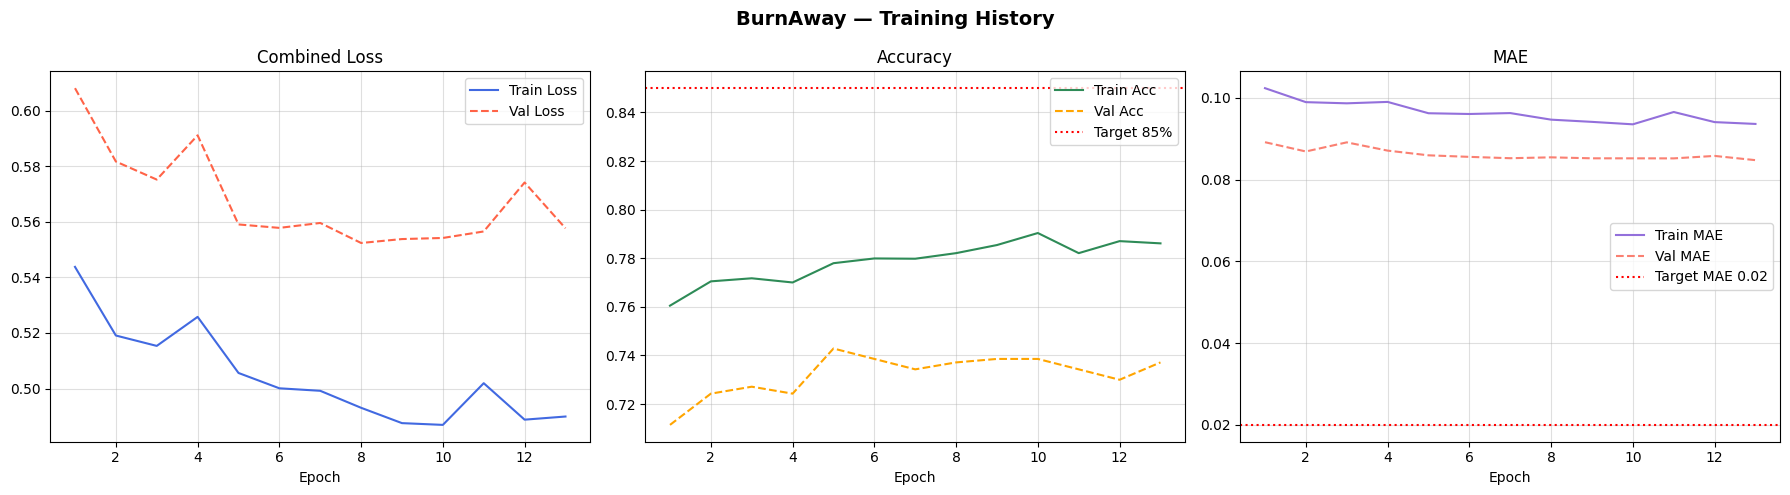


[BEST EPOCH] 5 | Val Acc: 0.7429 | Val MAE: 0.0859
[STATUS]     Akurasi: 74.29% [BELUM TERCAPAI] | MAE: 0.0859 [BELUM TERCAPAI]


In [102]:
def plot_training_history(history: dict) -> None:
    """Memvisualisasikan kurva training dan validasi dari history dictionary."""
    epochs_range = range(1, len(history['loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('BurnAway — Training History', fontsize=14, fontweight='bold')

    # Panel 1: Loss
    axes[0].plot(epochs_range, history['loss'],     label='Train Loss',  color='royalblue')
    axes[0].plot(epochs_range, history['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
    axes[0].set_title('Combined Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.4)

    # Panel 2: Accuracy
    axes[1].plot(epochs_range, history['accuracy'],     label='Train Acc', color='seagreen')
    axes[1].plot(epochs_range, history['val_accuracy'], label='Val Acc',   color='orange', linestyle='--')
    axes[1].axhline(TARGET_ACCURACY, color='red', linestyle=':', label=f'Target {TARGET_ACCURACY*100:.0f}%')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.4)

    # Panel 3: MAE
    axes[2].plot(epochs_range, history['mae'],     label='Train MAE', color='mediumpurple')
    axes[2].plot(epochs_range, history['val_mae'], label='Val MAE',   color='salmon', linestyle='--')
    axes[2].axhline(TARGET_MAE, color='red', linestyle=':', label=f'Target MAE {TARGET_MAE}')
    axes[2].set_title('MAE'); axes[2].set_xlabel('Epoch')
    axes[2].legend(); axes[2].grid(alpha=0.4)

    plt.tight_layout()
    plt.show()


plot_training_history(history)

# Ringkasan performa terbaik
best_epoch = int(np.argmax(history['val_accuracy'])) + 1
best_acc   = max(history['val_accuracy'])
best_mae   = history['val_mae'][best_epoch - 1]
print(f'\n[BEST EPOCH] {best_epoch} | Val Acc: {best_acc:.4f} | Val MAE: {best_mae:.4f}')
print(f'[STATUS]     {check_target_achieved(best_acc, best_mae)}')

# 17. Final Evaluation



 CLASSIFICATION PERFORMANCE 
              precision    recall  f1-score   support

         Low       0.60      0.84      0.70       159
      Medium       0.81      0.57      0.67       363
        High       0.69      0.87      0.77       178

    accuracy                           0.71       700
   macro avg       0.70      0.76      0.71       700
weighted avg       0.73      0.71      0.70       700



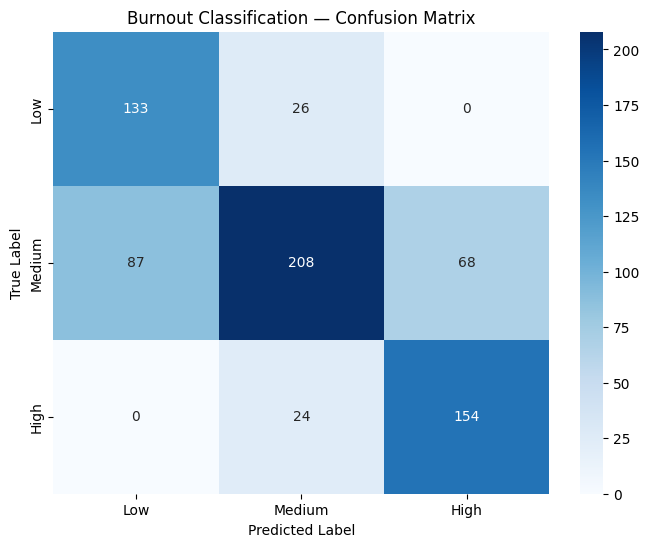


 REGRESSION PERFORMANCE 
Final Test MAE: 0.085977

[SUMMARY] Test Acc: 70.71% | Test MAE: 0.0860
[STATUS]  Akurasi: 70.71% [BELUM TERCAPAI] | MAE: 0.0860 [BELUM TERCAPAI]


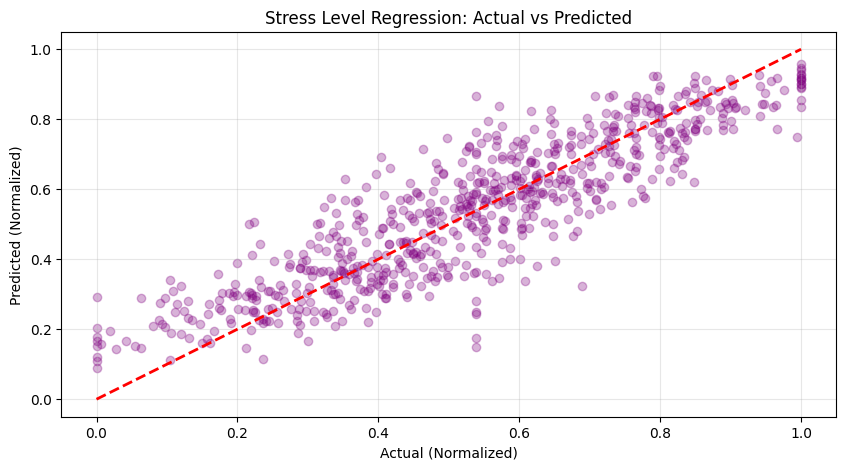

In [103]:
def evaluate_final_model(model, test_dataset, class_labels):
    """
    Evaluasi komprehensif pada data tes: Klasifikasi & Regresi.
    Menghasilkan classification report, confusion matrix, dan final MAE.
    """
    all_y_clf = []
    all_y_reg = []
    all_pred_clf = []
    all_pred_reg = []

    # Kumpulkan prediksi dan ground truth dari test set
    for x, y_clf, y_reg in test_dataset:
        clf_logits, reg_out = model(x, training=False)

        # Konversi logits ke class index
        pred_clf = tf.argmax(tf.nn.softmax(clf_logits), axis=1)

        all_y_clf.extend(y_clf.numpy())
        all_y_reg.extend(y_reg.numpy())
        all_pred_clf.extend(pred_clf.numpy())
        all_pred_reg.extend(reg_out.numpy().flatten())

    # 1. Metrik Klasifikasi
    print("\n" + "="*30)
    print(" CLASSIFICATION PERFORMANCE ")
    print("="*30)
    print(classification_report(all_y_clf, all_pred_clf, target_names=list(class_labels.values())))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_y_clf, all_pred_clf)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels.values(), yticklabels=class_labels.values())
    plt.title('Burnout Classification — Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 3. Metrik Regresi
    final_mae = np.mean(np.abs(np.array(all_y_reg) - np.array(all_pred_reg)))
    print("\n" + "="*30)
    print(" REGRESSION PERFORMANCE ")
    print("="*30)
    print(f"Final Test MAE: {final_mae:.6f}")

    # Cek apakah lolos passing grade
    test_acc = np.mean(np.array(all_y_clf) == np.array(all_pred_clf))
    print(f"\n[SUMMARY] Test Acc: {test_acc:.2%} | Test MAE: {final_mae:.4f}")
    print(f"[STATUS]  {check_target_achieved(test_acc, final_mae)}")
    # 4. Visualisasi Regresi (Actual vs Predicted)
    plt.figure(figsize=(10, 5))
    plt.scatter(all_y_reg, all_pred_reg, alpha=0.3, color='purple')
    plt.plot([0, 1], [0, 1], 'r--', lw=2) # Garis ideal
    plt.title('Stress Level Regression: Actual vs Predicted')
    plt.xlabel('Actual (Normalized)')
    plt.ylabel('Predicted (Normalized)')
    plt.grid(alpha=0.3)
    plt.show()

# Jalankan evaluasi
evaluate_final_model(model, test_dataset, CLASS_LABELS)

# 18. Inference Pipeline

Fungsi `predict_burnout` mengimplementasikan *inference pipeline* yang *production-ready*:
menerima **raw input dictionary** dari pengguna, menjalankan seluruh *preprocessing chain*
(validasi → scaling → prediksi), dan mengembalikan output terstruktur yang langsung dapat dikonsumsi oleh API layer.

```
Raw User Input (dict)
  → Validasi & Konversi ke NumPy
  → RobustScaler.transform()
  → model.predict()
  → Structured Output {label, confidence, stress_estimate}
```

In [105]:
def predict_burnout(raw_input: dict, inference_model=None, inference_scaler=None) -> dict:
    """
    Production-ready inference function.
    Menerima raw feature dictionary dan mengembalikan prediksi terstruktur.

    Args:
        raw_input: Dictionary fitur input pengguna (nama kolom → nilai).
        inference_model: Model yang sudah dilatih. Default: `best_model`.
        inference_scaler: Scaler yang sudah di-fit. Default: `scaler`.

    Returns:
        Dictionary dengan keys: label, confidence, class_probs, stress_estimate.
    """
    inf_model  = inference_model  or best_model
    inf_scaler = inference_scaler or scaler

    # Validasi kolom input
    missing = [c for c in FEATURE_COLS if c not in raw_input]
    if missing:
        raise ValueError(f'[ERROR] Fitur berikut tidak ditemukan dalam input: {missing}')

    # Konversi ke array NumPy
    x_raw  = np.array([[raw_input[c] for c in FEATURE_COLS]], dtype=np.float32)

    # Clip outlier untuk commit_bug_ratio
    cbr_idx = FEATURE_COLS.index('commit_bug_ratio') if 'commit_bug_ratio' in FEATURE_COLS else -1
    if cbr_idx >= 0:
        x_raw[0, cbr_idx] = min(x_raw[0, cbr_idx], 220.0)

    # Scaling
    x_scaled = inf_scaler.transform(x_raw).astype(np.float32)

    # Inference
    clf_logits, reg_out = inf_model.predict(x_scaled, verbose=0)
    probs          = tf.nn.softmax(clf_logits[0]).numpy()
    predicted_cls  = int(np.argmax(probs))
    stress_est     = float(reg_out[0, 0]) * 100  # denormalize ke skala 0–100

    result = {
        'label':          CLASS_LABELS[predicted_cls],
        'confidence':     float(probs[predicted_cls]),
        'class_probs':    {CLASS_LABELS[i]: float(p) for i, p in enumerate(probs)},
        'stress_estimate': round(stress_est, 2),
    }
    return result


# ── Contoh inference dengan sampel data ───────────────────────────────────
sample_input = {
    'age': 28.0, 'experience_years': 3.0, 'daily_work_hours': 11.5,
    'sleep_hours': 5.2, 'caffeine_intake': 5.0, 'bugs_per_day': 14.0,
    'commits_per_day': 7.0, 'meetings_per_day': 6.0, 'screen_time': 13.5,
    'exercise_hours': 0.3, 'stress_level': 78.0, 'work_sleep_ratio': 2.21,
    'screen_time_intensity': 1.17, 'commit_bug_ratio': 0.5, 'work_category': 1.0,
}

prediction = predict_burnout(sample_input, inference_model=model, inference_scaler=scaler)
print(f'\n{" INFERENCE RESULT ":=^50}')
print(f'  Label          : {prediction["label"]}')
print(f'  Confidence     : {prediction["confidence"]:.2%}')
print(f'  Stress Estimate: {prediction["stress_estimate"]:.1f} / 100')
print(f'  Class Probs    : { {k: f"{v:.2%}" for k, v in prediction["class_probs"].items()} }')
print('=' * 50)


================ INFERENCE RESULT ================
  Label          : High
  Confidence     : 97.56%
  Stress Estimate: 88.8 / 100
  Class Probs    : {'Low': '0.00%', 'Medium': '2.44%', 'High': '97.56%'}


# 19. Generative AI Advisory Layer

Layer *Generative AI* mengintegrasikan **Gemini** sebagai *advisory engine* yang menghasilkan rekomendasi kesehatan personal berdasarkan hasil prediksi burnout.
Implementasi mendukung **dua jalur routing** secara otomatis:

| Jalur | Kondisi | Mekanisme |
|:---|:---|:---|
| **SDK** | `GENAI_SDK_AVAILABLE = True` | `google.genai.Client` dengan streaming response |
| **REST Fallback** | SDK tidak tersedia | `requests.post()` langsung ke Gemini REST API |

*Advisory prompt* dikonstruksi secara dinamis dari hasil inferensi, mencakup tingkat burnout, skor kepercayaan, dan estimasi stres pengguna.

In [106]:
def build_advisory_prompt(prediction_result: dict, user_context: dict = None) -> str:
    """Membangun prompt Generative AI berdasarkan hasil prediksi burnout."""
    label       = prediction_result['label']
    confidence  = prediction_result['confidence']
    stress_est  = prediction_result['stress_estimate']
    class_probs = prediction_result['class_probs']

    prompt = (
        f"Kamu adalah asisten kesehatan mental profesional untuk developer perangkat lunak.\n"
        f"Berdasarkan analisis AI, developer ini terdeteksi berada di level burnout: **{label}** "
        f"(confidence: {confidence:.1%}).\n"
        f"Distribusi probabilitas kelas: {class_probs}.\n"
        f"Estimasi skor stres: {stress_est:.1f}/100.\n\n"
        f"Berikan 5 rekomendasi konkret dan personal dalam bahasa Indonesia yang:\n"
        f"1. Spesifik untuk level burnout '{label}'\n"
        f"2. Dapat langsung diterapkan oleh developer\n"
        f"3. Mencakup aspek: manajemen waktu, kesehatan fisik, dan produktivitas\n"
        f"Tutup dengan kalimat motivasi singkat."
    )
    return prompt


def get_burnout_advice_sdk(prompt: str) -> str:
    """Mengambil rekomendasi dari Gemini menggunakan google-genai SDK."""
    try:
        client   = genai.Client(api_key=GEMINI_API_KEY)
        response = client.models.generate_content(
            model=GEMINI_MODEL,
            contents=prompt,
        )
        return response.text
    except Exception as e:
        return f'[SDK ERROR] {str(e)}'


def get_burnout_advice_rest(prompt: str) -> str:
    """Fallback: Mengambil rekomendasi dari Gemini melalui REST API."""
    if not GEMINI_API_KEY:
        return '[INFO] GEMINI_API_KEY tidak ditemukan. Set environment variable GEMINI_API_KEY.'

    url     = f'{GEMINI_BASE_URL}/{GEMINI_MODEL}:generateContent?key={GEMINI_API_KEY}'
    payload = {
        'contents': [{'parts': [{'text': prompt}]}],
        'generationConfig': {'temperature': 0.7, 'maxOutputTokens': 1024},
    }
    try:
        resp = requests.post(url, json=payload, timeout=30)
        resp.raise_for_status()
        return resp.json()['candidates'][0]['content']['parts'][0]['text']
    except Exception as e:
        return f'[REST ERROR] {str(e)}'


def get_burnout_advice(prediction_result: dict) -> str:
    """Router utama: pilih SDK atau REST fallback secara otomatis."""
    prompt = build_advisory_prompt(prediction_result)
    if GENAI_SDK_AVAILABLE and GEMINI_API_KEY:
        advice = get_burnout_advice_sdk(prompt)
        route  = 'SDK'
    else:
        advice = get_burnout_advice_rest(prompt)
        route  = 'REST Fallback'

    print(f'[GenAI] Routing: {route} | Model: {GEMINI_MODEL}')
    return advice


# ── Jalankan Advisory Layer ────────────────────────────────────────────────
print(f'\n{" GEMINI ADVISORY LAYER ":=^55}')
advice = get_burnout_advice(prediction)
print(f'\n[REKOMENDASI UNTUK {prediction["label"].upper()} BURNOUT]')
print('-' * 55)
print(advice)
print('=' * 55)


================ GEMINI ADVISORY LAYER ================
[GenAI] Routing: REST Fallback | Model: gemini-2.5-flash

[REKOMENDASI UNTUK HIGH BURNOUT]
-------------------------------------------------------
[INFO] GEMINI_API_KEY tidak ditemukan. Set environment variable GEMINI_API_KEY.


# 20. Artifact Serialization & Export

Tahap terakhir mengekspor seluruh *pipeline artifacts* ke format *production-ready*:

| Artifact | Format | Lokasi | Kegunaan |
|:---|:---|:---|:---|
| `burnaway_model_best.keras` | `.keras` | `models/` | Model terbaik (checkpoint) |
| `burnaway_model.keras` | `.keras` | `models/` | Model final (epoch terakhir) |
| `scaler.joblib` | joblib | `models/` | RobustScaler untuk preprocessing |
| `feature_cols.json` | JSON | `api/` | Daftar & urutan kolom fitur untuk API |
| `class_labels.json` | JSON | `api/` | Mapping index → label nama kelas |

Semua artifact ini wajib disertakan bersama model dalam *deployment package* FastAPI.

In [108]:
import json as _json

def save_model_artifacts(
    final_model,
    fit_scaler,
    feature_columns: list,
    class_map: dict,
) -> None:
    """Menyimpan seluruh artifact pipeline: model, scaler, dan metadata."""

    # 1. Simpan model final (bukan checkpoint terbaik)
    final_model.save(str(MODEL_FINAL_PATH))
    print(f'  [SAVED] Model final          → {MODEL_FINAL_PATH}')

    # 2. Simpan scaler
    scaler_path = MODEL_SAVE_DIR / 'scaler.joblib'
    joblib.dump(fit_scaler, str(scaler_path))
    print(f'  [SAVED] RobustScaler         → {scaler_path}')

    # 3. Simpan feature columns list ke API dir
    feat_path = API_DIR / 'feature_cols.json'
    with open(feat_path, 'w', encoding='utf-8') as fp:
        _json.dump(feature_columns, fp, indent=2)
    print(f'  [SAVED] Feature columns      → {feat_path}')

    # 4. Simpan class labels mapping
    labels_path = API_DIR / 'class_labels.json'
    with open(labels_path, 'w', encoding='utf-8') as fp:
        _json.dump({str(k): v for k, v in class_map.items()}, fp, indent=2)
    print(f'  [SAVED] Class labels         → {labels_path}')

    # 5. Simpan ringkasan konfigurasi pipeline
    config_path = API_DIR / 'pipeline_config.json'
    config_meta = {
        'num_features':    len(feature_columns),
        'num_classes':     NUM_CLASSES,
        'attention_units': ATTENTION_UNITS,
        'scaler_type':     'RobustScaler',
        'model_format':    '.keras',
        'target_accuracy': TARGET_ACCURACY,
        'target_mae':      TARGET_MAE,
    }
    with open(config_path, 'w', encoding='utf-8') as fp:
        _json.dump(config_meta, fp, indent=2)
    print(f'  [SAVED] Pipeline config      → {config_path}')


print(f'\n{" ARTIFACT SERIALIZATION & EXPORT ":=^55}')
save_model_artifacts(model, scaler, FEATURE_COLS, CLASS_LABELS)

print(f'\n{" EXPORT SUMMARY ":=^55}')
for artifact in [MODEL_BEST_PATH, MODEL_FINAL_PATH,
                 MODEL_SAVE_DIR / 'scaler.joblib',
                 API_DIR / 'feature_cols.json',
                 API_DIR / 'class_labels.json',
                 API_DIR / 'pipeline_config.json']:
    exists = '✓' if artifact.exists() else '✗'
    print(f'  [{exists}] {artifact}')

print(f'\n[DONE] Semua artifact berhasil diekspor.')
print(f'       Pipeline BurnAway siap untuk deployment via FastAPI!')


=========== ARTIFACT SERIALIZATION & EXPORT ===========
  [SAVED] Model final          → models/burnaway_model.keras
  [SAVED] RobustScaler         → models/scaler.joblib
  [SAVED] Feature columns      → api/feature_cols.json
  [SAVED] Class labels         → api/class_labels.json
  [SAVED] Pipeline config      → api/pipeline_config.json

=================== EXPORT SUMMARY ====================
  [✗] models/burnaway_model_best.keras
  [✓] models/burnaway_model.keras
  [✓] models/scaler.joblib
  [✓] api/feature_cols.json
  [✓] api/class_labels.json
  [✓] api/pipeline_config.json

[DONE] Semua artifact berhasil diekspor.
       Pipeline BurnAway siap untuk deployment via FastAPI!
